# Model: Support Vector Regression (SVR)
**Owner:** DOEM Sreypok

## 6.1 Import Libraries
SVR requires scaled data, so we import the preprocessing helper and the evaluation metrics needed for this notebook.


In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

root = Path('..')
sys.path.insert(0, str(root / 'src'))
import preprocess
importlib.reload(preprocess)
from preprocess import load_dataset, preprocess_data


## 6.2 Feature Scaling
The `preprocess_data` function builds a `preprocessor` pipeline that imputes missing values, scales numeric features with `StandardScaler`, and encodes categorical values with `OneHotEncoder`.


In [2]:
data_path = root / 'data' / 'raw' / 'used_car_sales.csv'
df = load_dataset(data_path)
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)
print('preprocessor:', preprocessor)


X_train shape: (8000, 62)
X_test shape : (2000, 62)
y_train shape: (8000,)
y_test shape : (2000,)
preprocessor: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'mileage', 'horsepower',
                                  'number_of_seats', 'number_of_doors']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['brand', 'model', 'fuel_type', 'transmission',
                                  'Location', 'car_t

## 6.3 Initialize SVR Model
Create an SVR model with the RBF kernel and the key hyperparameters: `C`, `gamma`, and `epsilon`.


In [3]:
svr_model = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
svr_model


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## 6.4 Train SVR Model
Fit the SVR model using the scaled training data.


In [4]:
svr_model.fit(X_train, y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## 6.5 Make Predictions
Generate predictions on the test set.


In [5]:
y_pred = svr_model.predict(X_test)
y_pred[:10]


array([7604.30610285, 7688.2919595 , 7943.17654704, 8198.50727014,
       7889.08757287, 8266.40647678, 7605.91887654, 7685.83994924,
       7708.84666397, 7977.79325707])

## 6.6 Evaluate Model
Calculate mean absolute error, root mean squared error, and R² score.


In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')


MAE  : 700.09
RMSE : 868.76
R²   : 0.2685


## 6.7 Visualization
Plot actual vs predicted prices and the distribution of prediction errors.


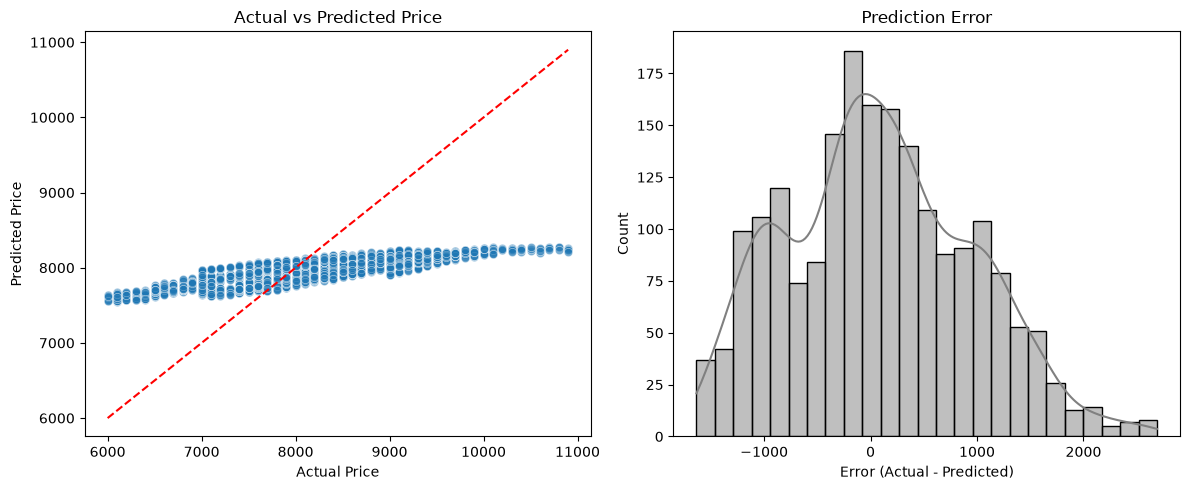

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
errors = y_test.to_numpy().flatten() - y_pred
sns.histplot(errors, kde=True, bins=25, color='gray')
plt.title('Prediction Error')
plt.xlabel('Error (Actual - Predicted)')
plt.tight_layout()
plt.show()


### Note
`preprocessor` is the fitted preprocessing pipeline from `src/preprocess.py`. It transforms raw feature columns by imputing missing values, scaling numeric features with `StandardScaler`, and encoding categorical values with `OneHotEncoder`. This gives SVR a clean numeric input matrix.
